# Neural Network — From Scratch (NumPy only)

**Read `README.md` first.** Every block cites the section (§) it implements.

The milestone: lesson 01's loop + lesson 02's neuron, stacked with bends. Total new machinery: one matrix multiply per layer, one derivation (§3.3), one initialization rule. Everything else you already own.

In [1]:
# Block 1 — Imports.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(88)

## Block 2 — The moons, split properly, and lesson 02 measured against them *(README §1, §2.2)*

Two interlocking crescents — the shape that broke K-means in lesson 09. Split first, scale with TRAIN-only statistics (lesson 03 §9's sealed exam), then the honest baseline: lesson 02's single neuron, so the motivation is a number.

300 points | balance {'A': 150, 'B': 150}


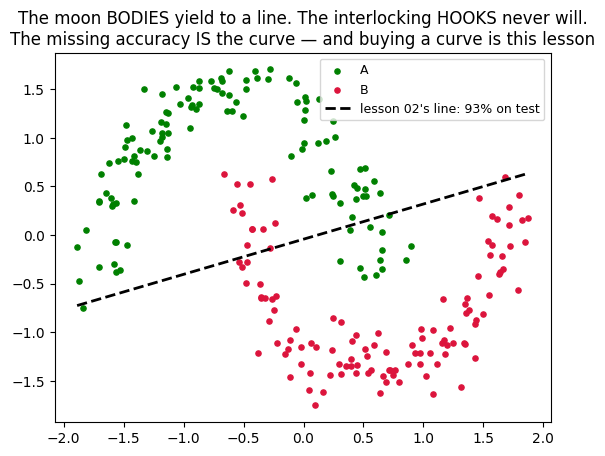

In [2]:
df = pd.read_csv("data/moons_data.csv")
X = df[["x1", "x2"]].values
y = (df.label == "B").astype(int).values
print(f"{len(y)} points | balance {df.label.value_counts().to_dict()}")

idx = np.random.permutation(len(y)); cut = int(0.8*len(y))
tr, te = idx[:cut], idx[cut:]
mu, sd = X[tr].mean(0), X[tr].std(0)              # train-only stats: the sealed exam
Xtr, Xte = (X[tr]-mu)/sd, (X[te]-mu)/sd
ytr, yte = y[tr], y[te]

def sigmoid(z): return 1/(1+np.exp(-z))

# lesson 02, verbatim, as the baseline
w, b = np.zeros(2), 0.0
for _ in range(3000):
    p = sigmoid(Xtr @ w + b)
    w -= 0.3 * (Xtr.T @ (p - ytr)) / len(ytr)
    b -= 0.3 * np.mean(p - ytr)
acc_lr = ((sigmoid(Xte @ w + b) > 0.5).astype(int) == yte).mean()

plt.scatter(Xtr[ytr==0,0], Xtr[ytr==0,1], c="green", s=14, label="A")
plt.scatter(Xtr[ytr==1,0], Xtr[ytr==1,1], c="crimson", s=14, label="B")
xs_ = np.linspace(Xtr[:,0].min(), Xtr[:,0].max(), 50)
plt.plot(xs_, (-b - w[0]*xs_)/w[1], "k--", lw=2, label=f"lesson 02's line: {acc_lr:.0%} on test")
plt.legend(fontsize=9)
plt.title("The moon BODIES yield to a line. The interlocking HOOKS never will.\nThe missing accuracy IS the curve — and buying a curve is this lesson")
plt.show()

## Block 3 — Why scaling is mandatory here, for a NEW reason *(README §4)*

Old reason (lessons 01–03): unscaled features distort the descent or the ruler. New reason: a first-layer neuron computes tanh(w·x+b), and tanh is FLAT beyond |z| ≈ 3. Feed it raw features in the hundreds and every neuron saturates on arrival — and README §3.3's backward pass multiplies each neuron's blame by its slope. Saturated neuron → slope ≈ 0 → learns nothing. Scaling keeps the neurons awake at birth.

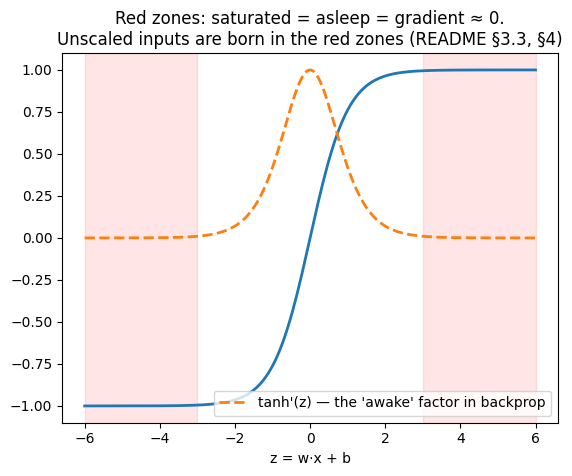

In [3]:
z = np.linspace(-6, 6, 200)
plt.plot(z, np.tanh(z), lw=2)
plt.plot(z, 1 - np.tanh(z)**2, lw=2, ls="--", label="tanh'(z) — the 'awake' factor in backprop")
plt.axvspan(-6, -3, alpha=0.1, color="red"); plt.axvspan(3, 6, alpha=0.1, color="red")
plt.legend(); plt.xlabel("z = w·x + b")
plt.title("Red zones: saturated = asleep = gradient ≈ 0.\nUnscaled inputs are born in the red zones (README §3.3, §4)")
plt.show()

## Block 4 — The forward pass, and the collapse proof *(README §3.1–3.2)*

Four lines: line-layer, bend, line-layer, squash. Then the one-line algebra that makes the bend non-negotiable: remove it and ANY depth is secretly lesson 01.

In [4]:
H = 8   # hidden width: 8 stripes to manufacture

def init_net(h=H, seed=0):
    rs = np.random.default_rng(seed)
    return {"W1": rs.normal(0, 0.5, (2, h)), "b1": np.zeros(h),   # random, NOT zero — README §3.4
            "W2": rs.normal(0, 0.5, (h, 1)), "b2": np.zeros(1)}

def forward(P, Xb):
    """README §3.1 — compose: lines, bend, line, squash."""
    Z1 = Xb @ P["W1"] + P["b1"]        # 8 of lesson 02's lines, at once
    A1 = np.tanh(Z1)                    # THE BEND (tanh: sigmoid's zero-centered cousin)
    Z2 = A1 @ P["W2"] + P["b2"]        # one more lesson 02 line, on the manufactured features
    return sigmoid(Z2[:, 0]), Z1, A1

# The collapse proof (README §3.2): remove the bend and two layers ARE one.
P = init_net()
no_bend   = (Xtr @ P["W1"] + P["b1"]) @ P["W2"] + P["b2"]
collapsed = Xtr @ (P["W1"] @ P["W2"]) + (P["b1"] @ P["W2"] + P["b2"])
print(f"two linear layers vs their one-layer collapse — max difference: {np.abs(no_bend - collapsed).max():.2e}")
print("Identical. Without the bend, depth is a costume (README §3.2).")

two linear layers vs their one-layer collapse — max difference: 2.22e-16
Identical. Without the bend, depth is a costume (README §3.2).


## Block 5 — The loss: imported from lesson 02, changed by zero *(README §3.1)*

In [5]:
def cross_entropy(p, y_true):
    """Lesson 02 §3.3, verbatim."""
    eps = 1e-12
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(y_true*np.log(p) + (1-y_true)*np.log(1-p))

p0, _, _ = forward(P, Xtr)
print(f"loss at random init: {cross_entropy(p0, ytr):.3f}   (clueless baseline ~0.693 = -log(0.5), lesson 02)")

loss at random init: 0.730   (clueless baseline ~0.693 = -log(0.5), lesson 02)


## Block 6 — The backward pass: the chain rule, one δ at a time *(README §3.3)*

Read each line against §3.3. The pattern to internalize: **δ = (blame from above, routed through the weights) × (local slope)** — and a weight's gradient = (what it carried) × (the δ where it delivered). Then the habit that catches 90% of backprop bugs: nudge one weight numerically and check the analytic gradient agrees.

In [6]:
def backward(P, Xb, yb, p, Z1, A1):
    """README §3.3 — every gradient, one backward sweep."""
    n = len(yb)
    d2 = (p - yb)[:, None] / n            # δ2 = ŷ − y : the lesson 02 miracle, first domino
    gW2 = A1.T @ d2                        # what W2 carried (A1) × blame at its destination (δ2)
    gb2 = d2.sum(axis=0)
    d1 = (d2 @ P["W2"].T) * (1 - A1**2)   # blame routed BACK through W2, gated by tanh' = 1−A1²
    #                        ^^^^^^^^^^    'how awake was each neuron' — asleep neurons learn nothing
    gW1 = Xb.T @ d1                        # same pattern, one level down
    gb1 = d1.sum(axis=0)
    return {"W1": gW1, "b1": gb1, "W2": gW2, "b2": gb2}

# Numerical gradient check:
P = init_net(seed=1)
p, Z1, A1 = forward(P, Xtr)
g = backward(P, Xtr, ytr, p, Z1, A1)
eps = 1e-5
P["W1"][0, 0] += eps; up, *_ = forward(P, Xtr); Lu = cross_entropy(up, ytr)
P["W1"][0, 0] -= 2*eps; dn, *_ = forward(P, Xtr); Ld = cross_entropy(dn, ytr)
P["W1"][0, 0] += eps
num = (Lu - Ld) / (2*eps)
print(f"analytic gradient for W1[0,0]: {g['W1'][0,0]:+.6f}")
print(f"numerical (nudge & remeasure): {num:+.6f}   <- agreement = the chain rule was applied correctly")

analytic gradient for W1[0,0]: -0.006260
numerical (nudge & remeasure): -0.006260   <- agreement = the chain rule was applied correctly


## Block 7 — The loop (lesson 01, verbatim), the movie, the score *(README §3.4, §2.5)*

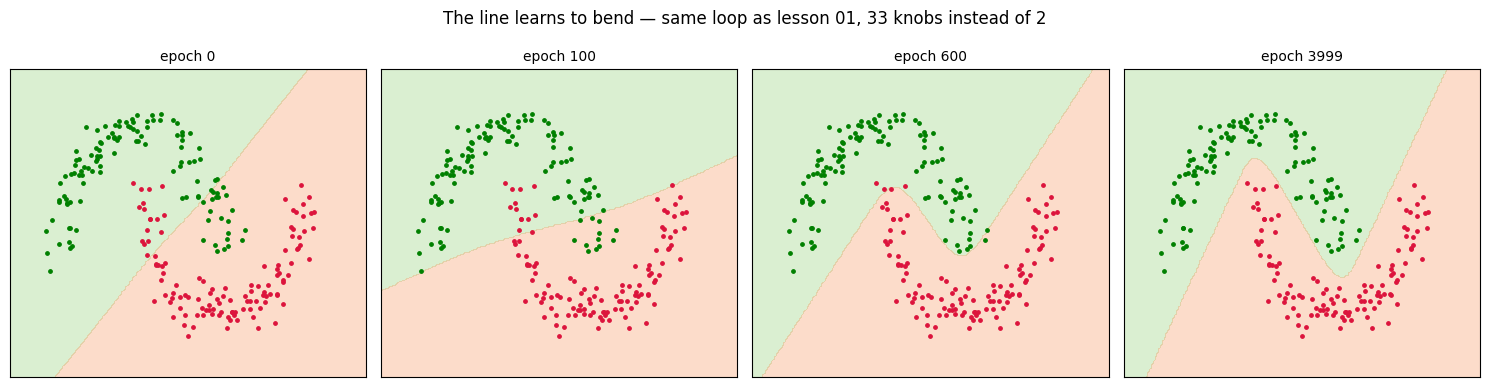

lesson 02 (one neuron): 93%   |   this lesson (8 hidden + 1): 100% on the sealed test set


In [7]:
def train(Xb, yb, h=H, lr=0.5, epochs=4000, seed=0, snap_at=()):
    P = init_net(h, seed)
    hist, snaps = [], {}
    for ep in range(epochs):
        p, Z1, A1 = forward(P, Xb)
        g = backward(P, Xb, yb, p, Z1, A1)
        for k in P: P[k] -= lr * g[k]              # lesson 01 §3.4 — for all 33 knobs at once
        hist.append(cross_entropy(p, yb))
        if ep in snap_at: snaps[ep] = {k: v.copy() for k, v in P.items()}
    return P, hist, snaps

P, hist, snaps = train(Xtr, ytr, snap_at=(0, 100, 600))
snaps[3999] = P

gx, gy = np.meshgrid(np.linspace(-2.4, 2.6, 200), np.linspace(-2.4, 2.4, 200))
G = np.c_[gx.ravel(), gy.ravel()]
fig, axes = plt.subplots(1, 4, figsize=(15, 3.9))
for ax, ep in zip(axes, sorted(snaps)):
    pg = forward(snaps[ep], G)[0].reshape(gx.shape)
    ax.contourf(gx, gy, (pg > 0.5).astype(int), alpha=0.3, cmap="RdYlGn_r", levels=[-.5,.5,1.5])
    ax.scatter(Xtr[ytr==0,0], Xtr[ytr==0,1], c="green", s=6)
    ax.scatter(Xtr[ytr==1,0], Xtr[ytr==1,1], c="crimson", s=6)
    ax.set_title(f"epoch {ep}", fontsize=10); ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("The line learns to bend — same loop as lesson 01, 33 knobs instead of 2")
plt.tight_layout(); plt.show()

acc_nn = ((forward(P, Xte)[0] > 0.5).astype(int) == yte).mean()
print(f"lesson 02 (one neuron): {acc_lr:.0%}   |   this lesson (8 hidden + 1): {acc_nn:.0%} on the sealed test set")

## Block 8 — The width knob: the U-curve's newest costume *(README §4)*

h = 1 is literally lesson 02. Sweep upward: capacity buys the curve, then starts buying noise. (With 300 clean-ish points the overfit side is gentle — watch the train/test GAP more than any drop.)

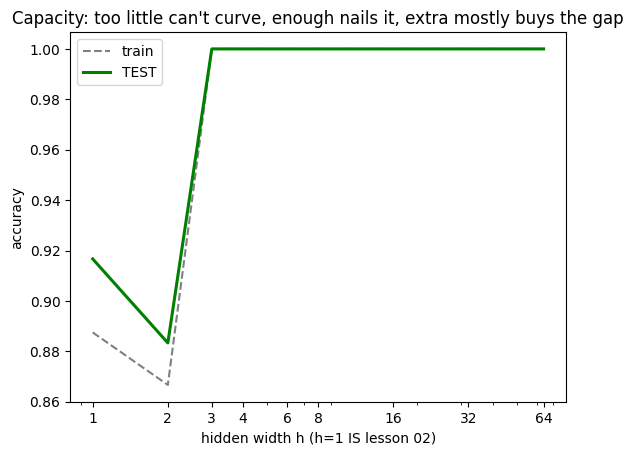

In [8]:
widths = [1, 2, 3, 4, 6, 8, 16, 32, 64]
tr_acc, te_acc = [], []
for h in widths:
    Ph, _, _ = train(Xtr, ytr, h=h, epochs=3000, seed=2)
    tr_acc.append(((forward(Ph, Xtr)[0] > 0.5).astype(int) == ytr).mean())
    te_acc.append(((forward(Ph, Xte)[0] > 0.5).astype(int) == yte).mean())

plt.plot(widths, tr_acc, "--", color="gray", label="train")
plt.plot(widths, te_acc, color="green", lw=2.2, label="TEST")
plt.xscale("log"); plt.xticks(widths, widths)
plt.xlabel("hidden width h (h=1 IS lesson 02)"); plt.ylabel("accuracy"); plt.legend()
plt.title("Capacity: too little can't curve, enough nails it, extra mostly buys the gap")
plt.show()

## Block 9 — The manufactured stripes *(README §2.3 — the lesson's deepest picture, live)*

Each hidden neuron over the input plane: one tilted, softly-bent stripe. The output blends them into a curve. Nobody designed these — blame flowing backward did.

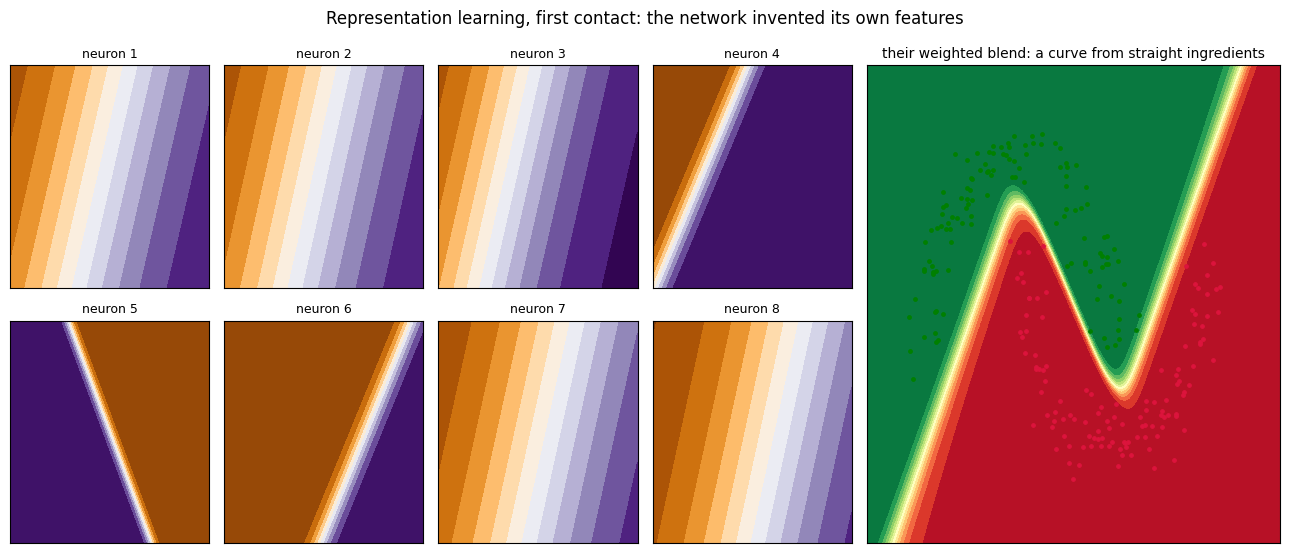

In [9]:
p_all, Z1g, A1g = forward(P, G)
fig = plt.figure(figsize=(13, 5.6))
gs = fig.add_gridspec(2, 6)
for i in range(8):
    ax = fig.add_subplot(gs[i//4, i%4])
    ax.contourf(gx, gy, A1g[:, i].reshape(gx.shape), levels=12, cmap="PuOr", vmin=-1, vmax=1)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title(f"neuron {i+1}", fontsize=9)
ax = fig.add_subplot(gs[:, 4:])
ax.contourf(gx, gy, p_all.reshape(gx.shape), levels=12, cmap="RdYlGn_r")
ax.scatter(Xtr[ytr==0,0], Xtr[ytr==0,1], c="green", s=6)
ax.scatter(Xtr[ytr==1,0], Xtr[ytr==1,1], c="crimson", s=6)
ax.set_xticks([]); ax.set_yticks([]); ax.set_title("their weighted blend: a curve from straight ingredients", fontsize=10)
plt.suptitle("Representation learning, first contact: the network invented its own features")
plt.tight_layout(); plt.show()

## Block 10 — Break it, then avenge history *(README §3.4 + the lesson 05 callback)*

(a) The symmetry trap: initialize every weight to zero — and watch learning die outright — with all-zero weights, gradients to BOTH weight matrices vanish and only the output bias can move; identical non-zero starts are the subtler version (permanent clones). (b) XOR: the shape whose 1969 exposure (a single neuron provably cannot solve it) froze neural networks for a decade. Lesson 05's trees carved it with boxes; now one hidden layer bends through it.

In [10]:
# (a) the symmetry trap
def train_zero_init(Xb, yb, h=H, lr=0.5, epochs=4000):
    P = {"W1": np.zeros((2, h)), "b1": np.zeros(h), "W2": np.zeros((h, 1)), "b2": np.zeros(1)}
    for _ in range(epochs):
        p, Z1, A1 = forward(P, Xb)
        g = backward(P, Xb, yb, p, Z1, A1)
        for k in P: P[k] -= lr * g[k]
    return P

Pz = train_zero_init(Xtr, ytr)
acc_z = ((forward(Pz, Xte)[0] > 0.5).astype(int) == yte).mean()
col_spread = np.abs(Pz["W1"] - Pz["W1"][:, :1]).max()
print(f"zero-init net after 4000 epochs: test acc {acc_z:.0%}   (random-init got {acc_nn:.0%})")
print(f"max difference between hidden neurons' weights: {col_spread:.2e}  <- 8 perfect clones (README §3.4)")
print("Total paralysis, in fact — worse than one neuron: with W2 = 0, no blame reaches the hidden")
print("layer (d1 = d2·W2ᵀ = 0), and with A1 = tanh(0) = 0, W2's own gradient (A1ᵀ·d2) is zero too.")
print("Only the output bias can move -> the net predicts one class forever. Even identical NON-zero")
print("starts leave the 8 neurons as permanent clones — the symmetry trap proper (README §3.4).\n")

# (b) XOR, avenged
rs = np.random.default_rng(5)
Xx = rs.uniform(-1, 1, (400, 2))
yx = ((Xx[:,0] > 0) ^ (Xx[:,1] > 0)).astype(int)      # the 1969 shape
Px, _, _ = train(Xx, yx, h=4, lr=0.8, epochs=4000, seed=3)
acc_x = ((forward(Px, Xx)[0] > 0.5).astype(int) == yx).mean()
print(f"XOR — one neuron: capped near coin-flip (no line exists). Four hidden neurons: {acc_x:.0%}.")
print("The problem that ended an era, dispatched by one hidden layer. Lesson 05 carved it with")
print("boxes; this lesson BENDS through it — and lessons 11–17 are this trick, scaled to the world.")

zero-init net after 4000 epochs: test acc 48%   (random-init got 100%)
max difference between hidden neurons' weights: 0.00e+00  <- 8 perfect clones (README §3.4)
Total paralysis, in fact — worse than one neuron: with W2 = 0, no blame reaches the hidden
layer (d1 = d2·W2ᵀ = 0), and with A1 = tanh(0) = 0, W2's own gradient (A1ᵀ·d2) is zero too.
Only the output bias can move -> the net predicts one class forever. Even identical NON-zero
starts leave the 8 neurons as permanent clones — the symmetry trap proper (README §3.4).



XOR — one neuron: capped near coin-flip (no line exists). Four hidden neurons: 94%.
The problem that ended an era, dispatched by one hidden layer. Lesson 05 carved it with
boxes; this lesson BENDS through it — and lessons 11–17 are this trick, scaled to the world.


---
## What you now own

- The forward pass as composition, and the collapse proof: the bend IS the model
- Backpropagation, derived and numerically verified: δ = (blame routed back) × (local slope), recursively — the chain rule with bookkeeping
- The symmetry-breaking rule, the width U-curve, the sleep factor (your first vanishing gradient)
- The deepest picture so far: hidden neurons as manufactured features — representation learning, first contact
- And a debt paid: XOR, 1969, avenged in four neurons

**Next:** `neural_network_with_library.ipynb` (sklearn's MLP + the PyTorch map) — then folder `11-cnns`: stop connecting everything to everything; let small pattern-detectors SLIDE.